In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

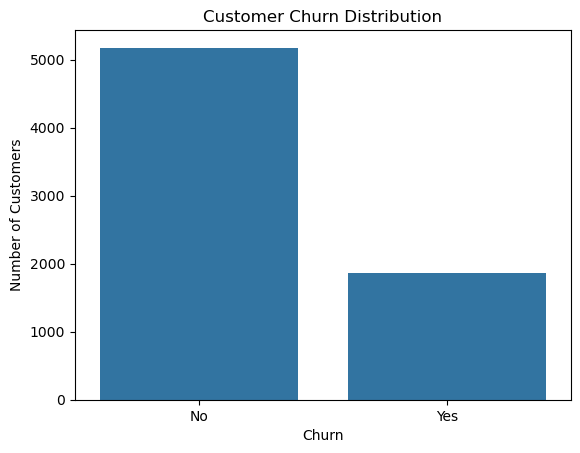

In [13]:
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [14]:
df["TotalCharges"].dtype

dtype('O')

In [15]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [16]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [17]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [18]:
df.dropna(subset=["TotalCharges"], inplace=True)

In [19]:
df.shape

(7032, 21)

In [20]:
df.duplicated().sum()

np.int64(0)

### EDA

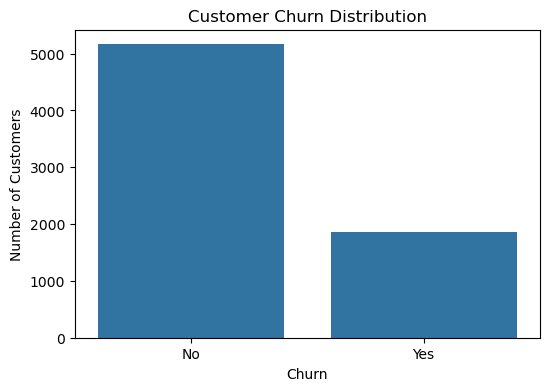

In [21]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [22]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


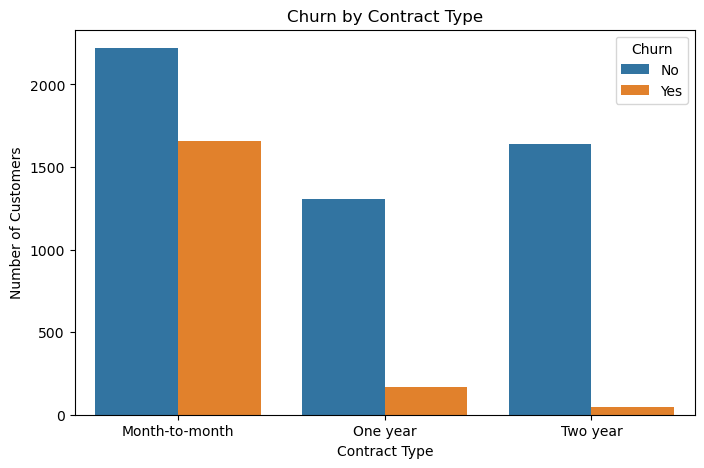

In [23]:
plt.figure(figsize=(8, 5))

sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

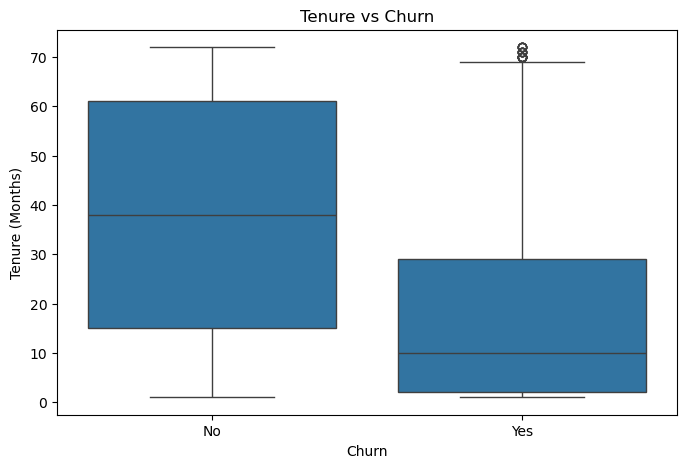

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

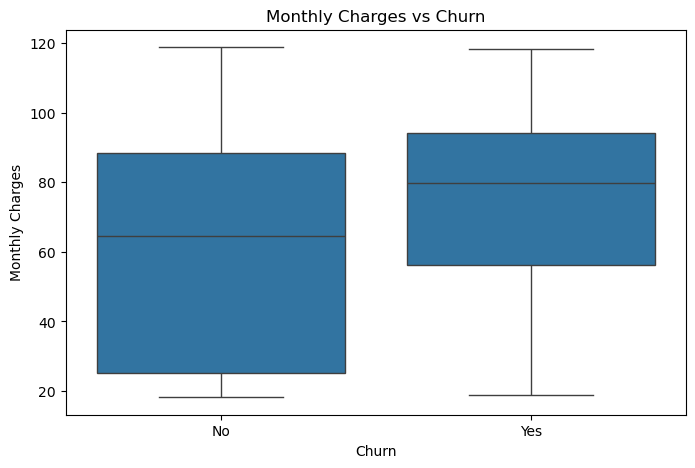

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

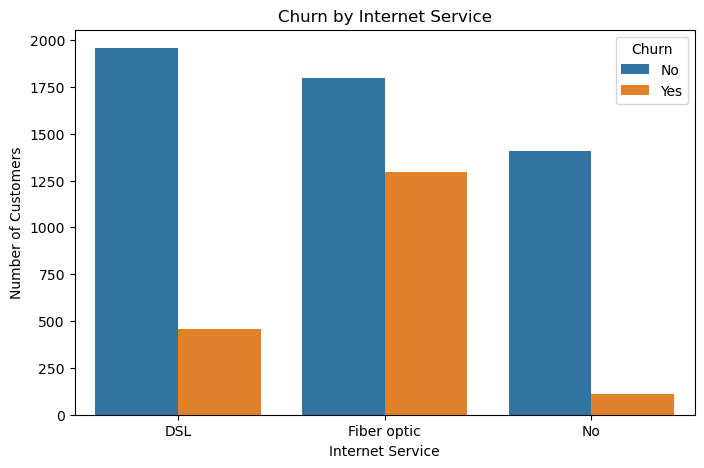

In [26]:
plt.figure(figsize=(8, 5))

sns.countplot(x="InternetService", hue="Churn", data=df)

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

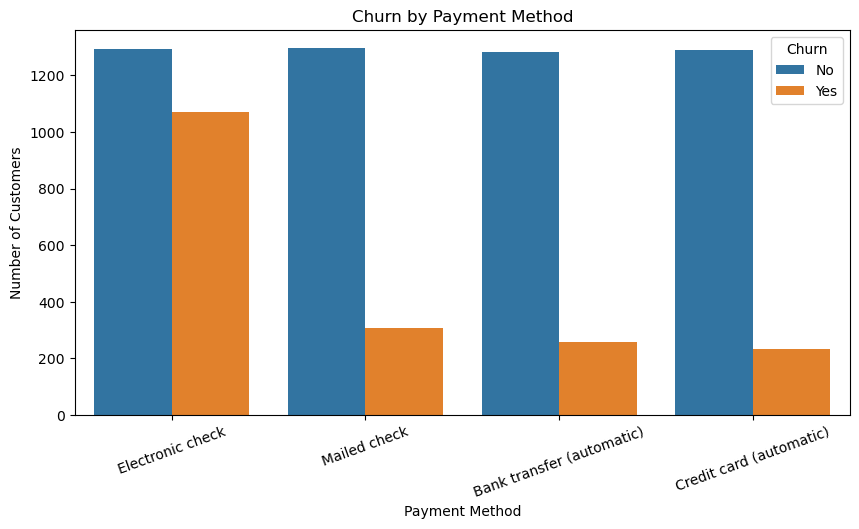

In [27]:
plt.figure(figsize=(10, 5))

sns.countplot(x="PaymentMethod", hue="Churn", data=df)

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

In [28]:
df.drop("customerID", axis=1, inplace=True)

In [29]:
df.shape

(7032, 20)

In [30]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [31]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [32]:
categorical_columns = df.select_dtypes(include="object").columns
numerical_columns = df.select_dtypes(exclude="object").columns

print("Categorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)

Categorical Columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object')


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [34]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 19)
y shape: (7032,)


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 19)
Testing data: (1407, 19)


In [37]:
categorical_features = X_train.select_dtypes(include=["object"]).columns
numerical_features = X_train.select_dtypes(exclude=["object"]).columns

print("Categorical Features:")
print(list(categorical_features))

print("\nNumerical Features:")
print(list(numerical_features))

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [39]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [40]:
print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

print("\nOriginal X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original X_train shape: (5625, 19)
Processed X_train shape: (5625, 45)

Original X_test shape: (1407, 19)
Processed X_test shape: (1407, 45)


In [41]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000)

In [42]:
y_pred = logistic_model.predict(X_test_processed)

y_pred[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

In [43]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8038379530916845


In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[917 116]
 [160 214]]


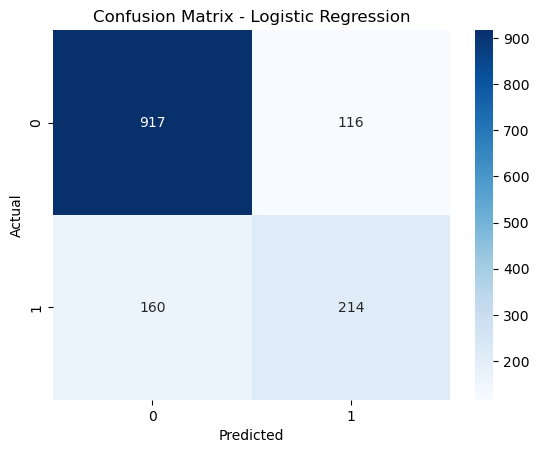

In [46]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [47]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(X_train_processed, y_train)

dt_pred = decision_tree.predict(X_test_processed)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.7896233120113717


In [48]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=8
)

random_forest.fit(X_train_processed, y_train)

rf_pred = random_forest.predict(X_test_processed)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7910447761194029


In [50]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)

knn.fit(X_train_processed, y_train)

knn_pred = knn.predict(X_test_processed)

print("KNN Accuracy:",
      accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.759772565742715


In [51]:
from sklearn.svm import SVC

svm = SVC(
    probability=True,
    random_state=42
)

svm.fit(X_train_processed, y_train)

svm_pred = svm.predict(X_test_processed)

print("SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.7917555081734187


In [52]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

model_results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,0.803838
4,SVM,0.791756
2,Random Forest,0.791045
1,Decision Tree,0.789623
3,KNN,0.759773


In [53]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "KNN": knn,
    "SVM": svm
}

predictions = {
    "Logistic Regression": y_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "KNN": knn_pred,
    "SVM": svm_pred
}

results = []

for name in models:
    pred = predictions[name]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,0.789623,0.602094,0.614973,0.608466
0,Logistic Regression,0.803838,0.648485,0.572193,0.607955
2,Random Forest,0.791045,0.636054,0.500000,0.559880
4,SVM,0.791756,0.640138,0.494652,0.558069
3,KNN,0.759773,0.546154,0.569519,0.557592


In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 8, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [56]:
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train_processed, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 8, 10], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [57]:
print("Best Parameters:")
print(rf_grid.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [58]:
print("Best Cross-Validation F1 Score:")
print(rf_grid.best_score_)

Best Cross-Validation F1 Score:
0.5870933196698719


In [59]:
best_rf = rf_grid.best_estimator_
print(best_rf)

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, random_state=42)


In [60]:
best_rf_pred = best_rf.predict(X_test_processed)

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, best_rf_pred))
print("Precision:", precision_score(y_test, best_rf_pred))
print("Recall   :", recall_score(y_test, best_rf_pred))
print("F1 Score :", f1_score(y_test, best_rf_pred))

Accuracy : 0.7917555081734187
Precision: 0.6363636363636364
Recall   : 0.5053475935828877
F1 Score : 0.563338301043219


In [62]:
best_rf_probability = best_rf.predict_proba(X_test_processed)[:, 1]

best_rf_auc = roc_auc_score(
    y_test,
    best_rf_probability
)

print("ROC-AUC:", best_rf_auc)

ROC-AUC: 0.8330119427864431


In [63]:
print("Original Random Forest")
print("----------------------")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC-AUC :", roc_auc_score(
    y_test,
    random_forest.predict_proba(X_test_processed)[:, 1]
))

print("\nTuned Random Forest")
print("-------------------")
print("Accuracy:", accuracy_score(y_test, best_rf_pred))
print("F1 Score:", f1_score(y_test, best_rf_pred))
print("ROC-AUC :", best_rf_auc)

Original Random Forest
----------------------
Accuracy: 0.7910447761194029
F1 Score: 0.5598802395209581
ROC-AUC : 0.8340472948838076

Tuned Random Forest
-------------------
Accuracy: 0.7917555081734187
F1 Score: 0.563338301043219
ROC-AUC : 0.8330119427864431


In [64]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_rf)
])

In [65]:
final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(max_depth=10, min_samples_leaf=2,
                                        min_samples_split=5, n_estimators=200,
                                        random_state=42))])

In [66]:
final_pred = final_pipeline.predict(X_test)

print(final_pred[:10])

[0 1 0 0 0 0 0 0 1 0]


In [67]:
final_probability = final_pipeline.predict_proba(X_test)[:, 1]

print(final_probability[:10])

[0.00668728 0.6939081  0.02091679 0.1202201  0.1736774  0.42459093
 0.01649604 0.11850379 0.62414035 0.01771995]


In [68]:
print("Final Model Performance")
print("-----------------------")

print("Accuracy :", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred))
print("Recall   :", recall_score(y_test, final_pred))
print("F1 Score :", f1_score(y_test, final_pred))
print("ROC-AUC  :", roc_auc_score(y_test, final_probability))

Final Model Performance
-----------------------
Accuracy : 0.7917555081734187
Precision: 0.6363636363636364
Recall   : 0.5053475935828877
F1 Score : 0.563338301043219
ROC-AUC  : 0.8330119427864431


In [69]:
print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



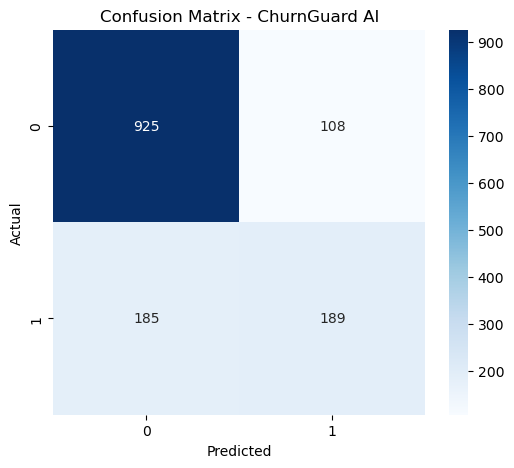

In [70]:
final_cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - ChurnGuard AI")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [71]:
import joblib

In [72]:
joblib.dump(
    final_pipeline,
    "churnguard_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [73]:
loaded_model = joblib.load("churnguard_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [74]:
loaded_prediction = loaded_model.predict(X_test)

print(loaded_prediction[:10])

[0 1 0 0 0 0 0 0 1 0]


### Prediction Function

In [76]:
def predict_churn(customer_data):
    
    prediction = loaded_model.predict(customer_data)[0]
    probability = loaded_model.predict_proba(customer_data)[0][1]
    
    return prediction, probability

In [77]:
def get_risk_level(probability):
    
    if probability < 0.30:
        return "LOW"
    
    elif probability < 0.60:
        return "MEDIUM"
    
    else:
        return "HIGH"

In [78]:
def get_retention_recommendation(risk_level):
    
    if risk_level == "HIGH":
        return [
            "Contact the customer personally",
            "Offer a personalized discount",
            "Provide priority technical support"
        ]
    
    elif risk_level == "MEDIUM":
        return [
            "Send a personalized retention offer",
            "Recommend a suitable long-term plan",
            "Check customer satisfaction"
        ]
    
    else:
        return [
            "Continue regular engagement",
            "Offer loyalty benefits",
            "Monitor customer activity"
        ]

In [79]:
sample_customer = X_test.iloc[[0]]

sample_customer

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
974,Female,0,Yes,Yes,59,Yes,No,DSL,No,Yes,No,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),75.95,4542.35


In [80]:
prediction, probability = predict_churn(sample_customer)

risk_level = get_risk_level(probability)

recommendations = get_retention_recommendation(risk_level)

print("Churn Prediction:", "Yes" if prediction == 1 else "No")
print("Churn Probability:", round(probability * 100, 2), "%")
print("Risk Level:", risk_level)

print("\nRetention Recommendations:")

for recommendation in recommendations:
    print("-", recommendation)

Churn Prediction: No
Churn Probability: 0.67 %
Risk Level: LOW

Retention Recommendations:
- Continue regular engagement
- Offer loyalty benefits
- Monitor customer activity


In [81]:
def analyze_customer(customer_data):
    
    prediction = loaded_model.predict(customer_data)[0]
    probability = loaded_model.predict_proba(customer_data)[0][1]
    
    risk_level = get_risk_level(probability)
    
    recommendations = get_retention_recommendation(risk_level)
    
    result = {
        "Prediction": "Likely to Churn" if prediction == 1 else "Likely to Stay",
        "Churn Probability": round(probability * 100, 2),
        "Risk Level": risk_level,
        "Recommendations": recommendations
    }
    
    return result

In [82]:
result = analyze_customer(sample_customer)

result

{'Prediction': 'Likely to Stay',
 'Churn Probability': np.float64(0.67),
 'Risk Level': 'LOW',
 'Recommendations': ['Continue regular engagement',
  'Offer loyalty benefits',
  'Monitor customer activity']}

In [83]:
# Get feature names after preprocessing

feature_names = final_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance from Random Forest

feature_importance = final_pipeline.named_steps["model"].feature_importances_

# Create DataFrame

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

# Sort by importance

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
1,num__tenure,0.145949
3,num__TotalCharges,0.124268
36,cat__Contract_Month-to-month,0.105251
2,num__MonthlyCharges,0.084174
18,cat__OnlineSecurity_No,0.054182
16,cat__InternetService_Fiber optic,0.048137
27,cat__TechSupport_No,0.042171
43,cat__PaymentMethod_Electronic check,0.039795
38,cat__Contract_Two year,0.031950
21,cat__OnlineBackup_No,0.019292


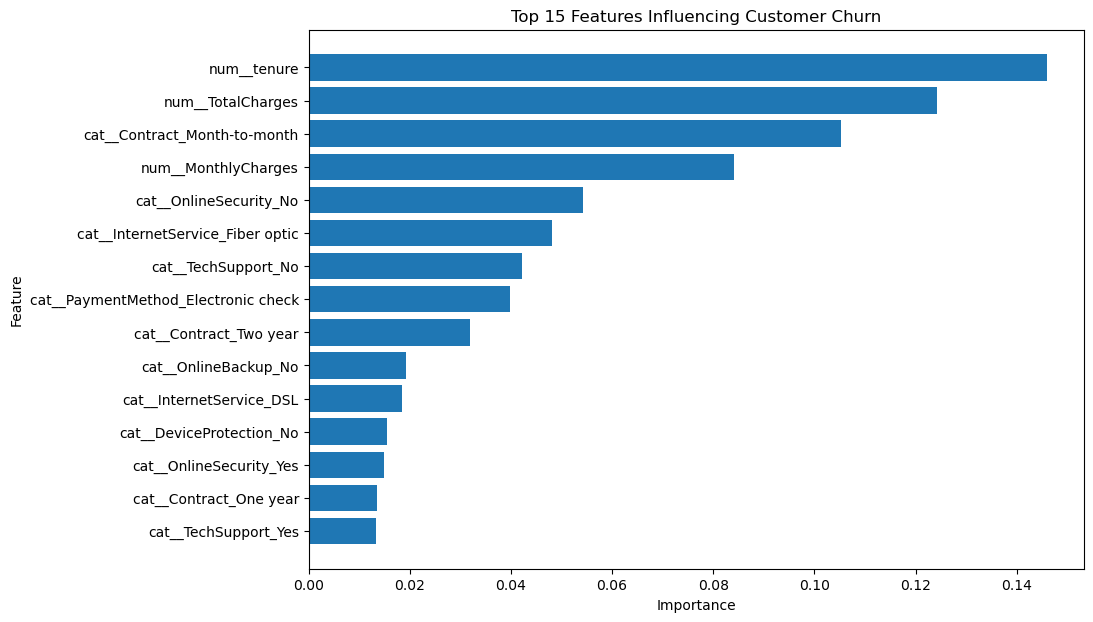

In [84]:
plt.figure(figsize=(10, 7))

top_features = importance_df.head(15).sort_values(
    by="Importance"
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features Influencing Customer Churn")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [85]:
print("Top 10 Important Features:\n")

for i, row in importance_df.head(10).iterrows():
    print(
        f"{row['Feature']} : "
        f"{row['Importance']:.4f}"
    )

Top 10 Important Features:

num__tenure : 0.1459
num__TotalCharges : 0.1243
cat__Contract_Month-to-month : 0.1053
num__MonthlyCharges : 0.0842
cat__OnlineSecurity_No : 0.0542
cat__InternetService_Fiber optic : 0.0481
cat__TechSupport_No : 0.0422
cat__PaymentMethod_Electronic check : 0.0398
cat__Contract_Two year : 0.0319
cat__OnlineBackup_No : 0.0193


In [86]:
importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!
